# 🏆 Classificador de Estratégia de Times Pokémon> Classifica automaticamente o archetype competitivo de um time.> Classes: Hyper Offense, Stall, Bulky Offense, Balance, Rain, Sand, Sun, Trick Room, HO Webs

In [1]:
!pip install -q xgboost lightgbm requests tqdm pandas numpy scikit-learn matplotlib seaborn
print("✅ Dependências instaladas!")

✅ Dependências instaladas!


In [2]:
import requests, json, random, warnings, pickle
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from pathlib import Path
from collections import defaultdict
from tqdm.notebook import tqdm
from concurrent.futures import ThreadPoolExecutor, as_completed
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
import xgboost as xgb
import lightgbm as lgb
warnings.filterwarnings('ignore')
random.seed(42); np.random.seed(42)
POKEAPI="https://pokeapi.co/api/v2"
CACHE=Path("poke_cache"); CACHE.mkdir(exist_ok=True)
print("✅ Imports prontos")

✅ Imports prontos


## 1. Coleta de Dados (PokeAPI + Smogon)

In [3]:
def fetch(url, key):
    f=CACHE/f"{key}.json"
    if f.exists():
        with open(f,'r') as fh: return json.load(fh)
    try:
        r=requests.get(url,timeout=30); r.raise_for_status(); d=r.json()
        with open(f,'w') as fh: json.dump(d,fh)
        return d
    except: return None

print("🔄 Coletando dados de Pokémon...")
pokemon_db={}
def fetch_poke(pid):
    p=fetch(f"{POKEAPI}/pokemon/{pid}",f"p_{pid}")
    s=fetch(f"{POKEAPI}/pokemon-species/{pid}",f"s_{pid}")
    if not p: return None
    types=[t["type"]["name"] for t in p["types"]]
    stats={st["stat"]["name"]:st["base_stat"] for st in p["stats"]}
    abilities=[a["ability"]["name"] for a in p.get("abilities",[])]
    name=p["name"]
    return {"name":name,"types":types,"hp":stats.get("hp",0),"attack":stats.get("attack",0),
            "defense":stats.get("defense",0),"sp_attack":stats.get("special-attack",0),
            "sp_defense":stats.get("special-defense",0),"speed":stats.get("speed",0),
            "abilities":abilities,"bst":sum(stats.values())}

with ThreadPoolExecutor(max_workers=10) as ex:
    futs={ex.submit(fetch_poke,i):i for i in range(1,1026)}
    for fut in tqdm(as_completed(futs),total=1025,desc="Pokémon"):
        r=fut.result()
        if r: pokemon_db[r["name"]]=r
print(f"✅ {len(pokemon_db)} Pokémon coletados")

🔄 Coletando dados de Pokémon...


Pokémon:   0%|          | 0/1025 [00:00<?, ?it/s]

✅ 1025 Pokémon coletados


In [4]:
# Smogon data para movesets e roles
SMOGON_URL="https://www.smogon.com/stats/2026-04/chaos/gen9ou-1500.json"
print("🔄 Baixando Smogon chaos data...")
try:
    smogon=requests.get(SMOGON_URL,timeout=60).json().get("data",{})
    print(f"✅ Smogon: {len(smogon)} Pokémon")
except:
    smogon={}
    print("⚠️ Smogon indisponível, usando apenas PokeAPI")

# Extrair moves comuns por Pokémon
pokemon_moves={}
for pname,pdata in smogon.items():
    moves=list(pdata.get("Moves",{}).keys())
    pokemon_moves[pname.lower().replace(" ","")]=moves
print(f"✅ Movesets extraídos: {len(pokemon_moves)} Pokémon")

🔄 Baixando Smogon chaos data...
✅ Smogon: 408 Pokémon
✅ Movesets extraídos: 408 Pokémon


## 2. Regras Heurísticas Sofisticadas para Archetypes

In [5]:
# Definição de roles e indicadores por archetype
WEATHER_SETTERS={"drizzle":["pelipper","politoed","kyogre"],"drought":["torkoal","groudon","ninetales"],
    "sand-stream":["tyranitar","hippowdon","gigalith"],"snow-warning":["abomasnow","ninetales-alola","aurorus"]}
WEATHER_ABUSERS={"rain":{"abilities":["swift-swim","rain-dish","dry-skin"],"moves":["thunder","hurricane","weather-ball"]},
    "sun":{"abilities":["chlorophyll","solar-power","flower-gift"],"moves":["solar-beam","solar-blade","growth","weather-ball"]},
    "sand":{"abilities":["sand-rush","sand-force","sand-veil"],"types":["rock","ground","steel"]},
    "hail":{"abilities":["slush-rush","ice-body"],"types":["ice"]}}
SETUP_MOVES=["swords-dance","dragon-dance","nasty-plot","calm-mind","bulk-up","quiver-dance",
    "shell-smash","shift-gear","coil","iron-defense","cotton-guard","agility","autotomize","rock-polish"]
HAZARD_MOVES=["stealth-rock","spikes","toxic-spikes","sticky-web"]
HAZARD_REMOVAL=["rapid-spin","defog","court-change","tidy-up","mortal-spin"]
RECOVERY_MOVES=["recover","roost","soft-boiled","slack-off","synthesis","moonlight","morning-sun",
    "shore-up","strength-sap","milk-drink","wish","rest"]
PIVOT_MOVES=["u-turn","volt-switch","flip-turn","teleport","parting-shot","baton-pass"]
STATUS_MOVES=["toxic","will-o-wisp","thunder-wave","glare","nuzzle","yawn"]
TRICK_ROOM_SETTERS=["trick-room"]
STICKY_WEB_SETTERS=["shuckle","ribombee","araquanid","galvantula","smeargle","masquerain","leavanny","orbeetle","spidops"]
STALL_ABILITIES=["unaware","regenerator","natural-cure","magic-guard","magic-bounce","poison-heal"]
WALL_POKEMON=["toxapex","ferrothorn","blissey","chansey","skarmory","corviknight","clefable","slowbro",
    "hippowdon","gliscor","mandibuzz","quagsire","dondozo","clodsire","garganacl","great-tusk"]

def get_moves(name):
    key=name.lower().replace(" ","").replace("-","")
    return pokemon_moves.get(key,[])

def has_ability(poke_data, ability_list):
    return any(a in ability_list for a in poke_data.get("abilities",[]))

def has_weather_setter(team):
    for weather, setters in WEATHER_SETTERS.items():
        for p in team:
            if p["name"] in setters or has_ability(p,[weather]):
                return weather
    return None

def count_feature(team, move_list):
    c=0
    for p in team:
        moves=get_moves(p["name"])
        if any(m in move_list for m in moves): c+=1
    return c

print("✅ Regras heurísticas definidas")

✅ Regras heurísticas definidas


## 3. Geração de Dataset Sintético de Times

In [6]:
# Pools de Pokémon por archetype
all_pokes=list(pokemon_db.values())
ou_pokes=[pokemon_db[n.lower()] for n in smogon.keys() if n.lower() in pokemon_db] if smogon else all_pokes[:200]
if len(ou_pokes)<30: ou_pokes=all_pokes[:200]

def pick_random(pool, n, must_include=None):
    team=list(must_include or [])
    remaining=[p for p in pool if p["name"] not in [t["name"] for t in team]]
    random.shuffle(remaining)
    team.extend(remaining[:n-len(team)])
    return team[:n]

def gen_rain_team():
    setters=[p for p in all_pokes if p["name"] in WEATHER_SETTERS.get("drizzle",[])]
    abusers=[p for p in all_pokes if has_ability(p,WEATHER_ABUSERS["rain"]["abilities"]) or "water" in p["types"]]
    if not setters: return None
    team=[random.choice(setters)]
    ab=random.sample(abusers[:20],min(3,len(abusers[:20])))
    team.extend(ab)
    fillers=[p for p in ou_pokes if p not in team][:50]
    team.extend(random.sample(fillers,min(6-len(team),len(fillers))))
    return team[:6]

def gen_sand_team():
    setters=[p for p in all_pokes if p["name"] in WEATHER_SETTERS.get("sand-stream",[])]
    abusers=[p for p in all_pokes if has_ability(p,["sand-rush","sand-force"]) or all(t in ["rock","ground","steel"] for t in p["types"])]
    if not setters: return None
    team=[random.choice(setters)]
    team.extend(random.sample(abusers[:15],min(2,len(abusers[:15]))))
    fillers=[p for p in ou_pokes if p not in team][:50]
    team.extend(random.sample(fillers,min(6-len(team),len(fillers))))
    return team[:6]

def gen_sun_team():
    setters=[p for p in all_pokes if p["name"] in WEATHER_SETTERS.get("drought",[])]
    abusers=[p for p in all_pokes if has_ability(p,WEATHER_ABUSERS["sun"]["abilities"]) or "fire" in p["types"]]
    if not setters: return None
    team=[random.choice(setters)]
    ab=random.sample(abusers[:15],min(3,len(abusers[:15])))
    team.extend(ab)
    fillers=[p for p in ou_pokes if p not in team][:50]
    team.extend(random.sample(fillers,min(6-len(team),len(fillers))))
    return team[:6]

def gen_trick_room():
    slow=[p for p in all_pokes if p["speed"]<=55 and p["bst"]>=400]
    if len(slow)<4: return None
    team=random.sample(slow[:30],min(5,len(slow[:30])))
    fillers=[p for p in ou_pokes if p not in team][:50]
    team.extend(random.sample(fillers,min(6-len(team),len(fillers))))
    return team[:6]

def gen_stall():
    walls=[p for p in all_pokes if (p["defense"]+p["sp_defense"])>200 and p["hp"]>=70]
    if len(walls)<4: return None
    team=random.sample(walls[:30],min(5,len(walls[:30])))
    fillers=[p for p in ou_pokes if p not in team and p["defense"]>=80][:30]
    if fillers: team.extend(random.sample(fillers,min(6-len(team),len(fillers))))
    return team[:6]

def gen_ho():
    sweepers=[p for p in all_pokes if (p["attack"]>=110 or p["sp_attack"]>=110) and p["speed"]>=80]
    if len(sweepers)<4: return None
    team=random.sample(sweepers[:40],min(5,len(sweepers[:40])))
    fillers=[p for p in ou_pokes if p not in team][:50]
    team.extend(random.sample(fillers,min(6-len(team),len(fillers))))
    return team[:6]

def gen_bulky_offense():
    bulky_attackers=[p for p in all_pokes if (p["attack"]>=90 or p["sp_attack"]>=90) and (p["defense"]>=80 or p["sp_defense"]>=80)]
    if len(bulky_attackers)<4: return None
    team=random.sample(bulky_attackers[:40],min(4,len(bulky_attackers[:40])))
    fillers=[p for p in ou_pokes if p not in team][:50]
    team.extend(random.sample(fillers,min(6-len(team),len(fillers))))
    return team[:6]

def gen_balance():
    mixed=ou_pokes if ou_pokes else all_pokes[:150]
    if len(mixed)<6: return None
    team=random.sample(mixed[:80],6)
    return team

def gen_ho_webs():
    webbers=[p for p in all_pokes if p["name"] in STICKY_WEB_SETTERS]
    sweepers=[p for p in all_pokes if (p["attack"]>=100 or p["sp_attack"]>=100) and p["speed"]>=70]
    if not webbers or len(sweepers)<3: return None
    team=[random.choice(webbers)]
    team.extend(random.sample(sweepers[:30],min(4,len(sweepers[:30]))))
    fillers=[p for p in ou_pokes if p not in team][:50]
    team.extend(random.sample(fillers,min(6-len(team),len(fillers))))
    return team[:6]

# Gerar dataset
SAMPLES_PER_CLASS=300
generators={"Hyper Offense":gen_ho,"Stall":gen_stall,"Bulky Offense":gen_bulky_offense,
    "Balance":gen_balance,"Rain":gen_rain_team,"Sand":gen_sand_team,"Sun":gen_sun_team,
    "Trick Room":gen_trick_room,"HO Webs":gen_ho_webs}

print("🔄 Gerando times sintéticos...")
teams_data=[]
for label, gen_fn in generators.items():
    count=0
    attempts=0
    while count<SAMPLES_PER_CLASS and attempts<SAMPLES_PER_CLASS*5:
        team=gen_fn()
        attempts+=1
        if team and len(team)==6:
            teams_data.append({"team":team,"label":label})
            count+=1
    print(f"  ✅ {label}: {count} times gerados")

random.shuffle(teams_data)
print(f"\n✅ Total: {len(teams_data)} times gerados")

🔄 Gerando times sintéticos...
  ✅ Hyper Offense: 300 times gerados
  ✅ Stall: 300 times gerados
  ✅ Bulky Offense: 300 times gerados
  ✅ Balance: 300 times gerados
  ✅ Rain: 300 times gerados
  ✅ Sand: 300 times gerados
  ✅ Sun: 300 times gerados
  ✅ Trick Room: 300 times gerados
  ✅ HO Webs: 300 times gerados

✅ Total: 2700 times gerados


## 4. Feature Engineering

In [7]:
TYPE_LIST=["normal","fire","water","grass","electric","ice","fighting","poison","ground",
    "flying","psychic","bug","rock","ghost","dragon","dark","steel","fairy"]

def extract_features(team):
    f={}
    stats_keys=["hp","attack","defense","sp_attack","sp_defense","speed","bst"]
    for s in stats_keys:
        vals=[p[s] for p in team]
        f[f"{s}_mean"]=np.mean(vals); f[f"{s}_max"]=np.max(vals)
        f[f"{s}_min"]=np.min(vals); f[f"{s}_std"]=np.std(vals)
    # Type counts
    type_counts=defaultdict(int)
    for p in team:
        for t in p["types"]: type_counts[t]+=1
    for t in TYPE_LIST: f[f"type_{t}"]=type_counts.get(t,0)
    f["unique_types"]=len(set(t for p in team for t in p["types"]))
    # Weather
    ws=has_weather_setter(team)
    f["has_rain"]=1 if ws=="drizzle" else 0
    f["has_sand"]=1 if ws=="sand-stream" else 0
    f["has_sun"]=1 if ws=="drought" else 0
    f["has_hail"]=1 if ws=="snow-warning" else 0
    # Roles
    f["setup_count"]=count_feature(team,SETUP_MOVES)
    f["hazard_count"]=count_feature(team,HAZARD_MOVES)
    f["removal_count"]=count_feature(team,HAZARD_REMOVAL)
    f["recovery_count"]=count_feature(team,RECOVERY_MOVES)
    f["pivot_count"]=count_feature(team,PIVOT_MOVES)
    f["status_count"]=count_feature(team,STATUS_MOVES)
    # Defensive/offensive ratio
    total_off=sum(p["attack"]+p["sp_attack"] for p in team)
    total_def=sum(p["defense"]+p["sp_defense"]+p["hp"] for p in team)
    f["off_def_ratio"]=total_off/(total_def+1)
    # Speed tiers
    speeds=sorted([p["speed"] for p in team])
    f["speed_below_60"]=sum(1 for s in speeds if s<60)
    f["speed_above_100"]=sum(1 for s in speeds if s>100)
    f["speed_range"]=speeds[-1]-speeds[0]
    # Walls
    f["wall_count"]=sum(1 for p in team if p["name"] in WALL_POKEMON)
    f["stall_ability"]=sum(1 for p in team if has_ability(p,STALL_ABILITIES))
    # Web setter
    f["has_webs"]=1 if any(p["name"] in STICKY_WEB_SETTERS for p in team) else 0
    return f

print("🔄 Extraindo features...")
features=[]; labels=[]
for td in tqdm(teams_data,desc="Features"):
    features.append(extract_features(td["team"]))
    labels.append(td["label"])

X=pd.DataFrame(features); y=np.array(labels)
le=LabelEncoder(); y_enc=le.fit_transform(y)
print(f"✅ Features: {X.shape}")
print(f"Classes: {le.classes_}")

🔄 Extraindo features...


Features:   0%|          | 0/2700 [00:00<?, ?it/s]

✅ Features: (2700, 64)
Classes: ['Balance' 'Bulky Offense' 'HO Webs' 'Hyper Offense' 'Rain' 'Sand' 'Stall'
 'Sun' 'Trick Room']


## 5. Treinamento e Comparação de Modelos

In [8]:
X_train,X_test,y_train,y_test=train_test_split(X,y_enc,test_size=0.2,random_state=42,stratify=y_enc)
scaler=StandardScaler(); X_train_s=scaler.fit_transform(X_train); X_test_s=scaler.transform(X_test)

models={"Random Forest":RandomForestClassifier(n_estimators=200,max_depth=15,random_state=42),
    "XGBoost":xgb.XGBClassifier(n_estimators=200,max_depth=8,learning_rate=0.1,random_state=42,
        eval_metric='mlogloss',use_label_encoder=False),
    "LightGBM":lgb.LGBMClassifier(n_estimators=200,max_depth=8,learning_rate=0.1,random_state=42,verbose=-1),
    "Logistic Regression":LogisticRegression(max_iter=2000,random_state=42,multi_class='multinomial')}

results={}
print("🔄 Treinando modelos...\n")
for name,model in models.items():
    use_scaled = name=="Logistic Regression"
    Xtr=X_train_s if use_scaled else X_train
    Xte=X_test_s if use_scaled else X_test
    model.fit(Xtr,y_train)
    y_pred=model.predict(Xte)
    acc=accuracy_score(y_test,y_pred)
    f1=f1_score(y_test,y_pred,average='weighted')
    cv=cross_val_score(model,scaler.transform(X) if use_scaled else X,y_enc,cv=5,scoring='f1_weighted').mean()
    results[name]={"accuracy":acc,"f1":f1,"cv_f1":cv,"model":model,"y_pred":y_pred}
    print(f"📊 {name}: Acc={acc:.4f} | F1={f1:.4f} | CV-F1={cv:.4f}")

best=max(results.items(),key=lambda x:x[1]["f1"])
print(f"\n🏆 Melhor modelo: {best[0]} (F1={best[1]['f1']:.4f})")

🔄 Treinando modelos...

📊 Random Forest: Acc=0.9630 | F1=0.9628 | CV-F1=0.9663
📊 XGBoost: Acc=0.9704 | F1=0.9704 | CV-F1=0.9687
📊 LightGBM: Acc=0.9778 | F1=0.9778 | CV-F1=0.9765
📊 Logistic Regression: Acc=0.9833 | F1=0.9833 | CV-F1=0.9787

🏆 Melhor modelo: Logistic Regression (F1=0.9833)


## 6. Métricas e Matriz de Confusão

📊 Classification Report - Logistic Regression:

               precision    recall  f1-score   support

      Balance       0.98      0.97      0.97        60
Bulky Offense       0.97      0.93      0.95        60
      HO Webs       0.97      1.00      0.98        60
Hyper Offense       0.98      0.98      0.98        60
         Rain       1.00      0.98      0.99        60
         Sand       1.00      1.00      1.00        60
        Stall       0.98      0.98      0.98        60
          Sun       0.98      1.00      0.99        60
   Trick Room       0.98      1.00      0.99        60

     accuracy                           0.98       540
    macro avg       0.98      0.98      0.98       540
 weighted avg       0.98      0.98      0.98       540



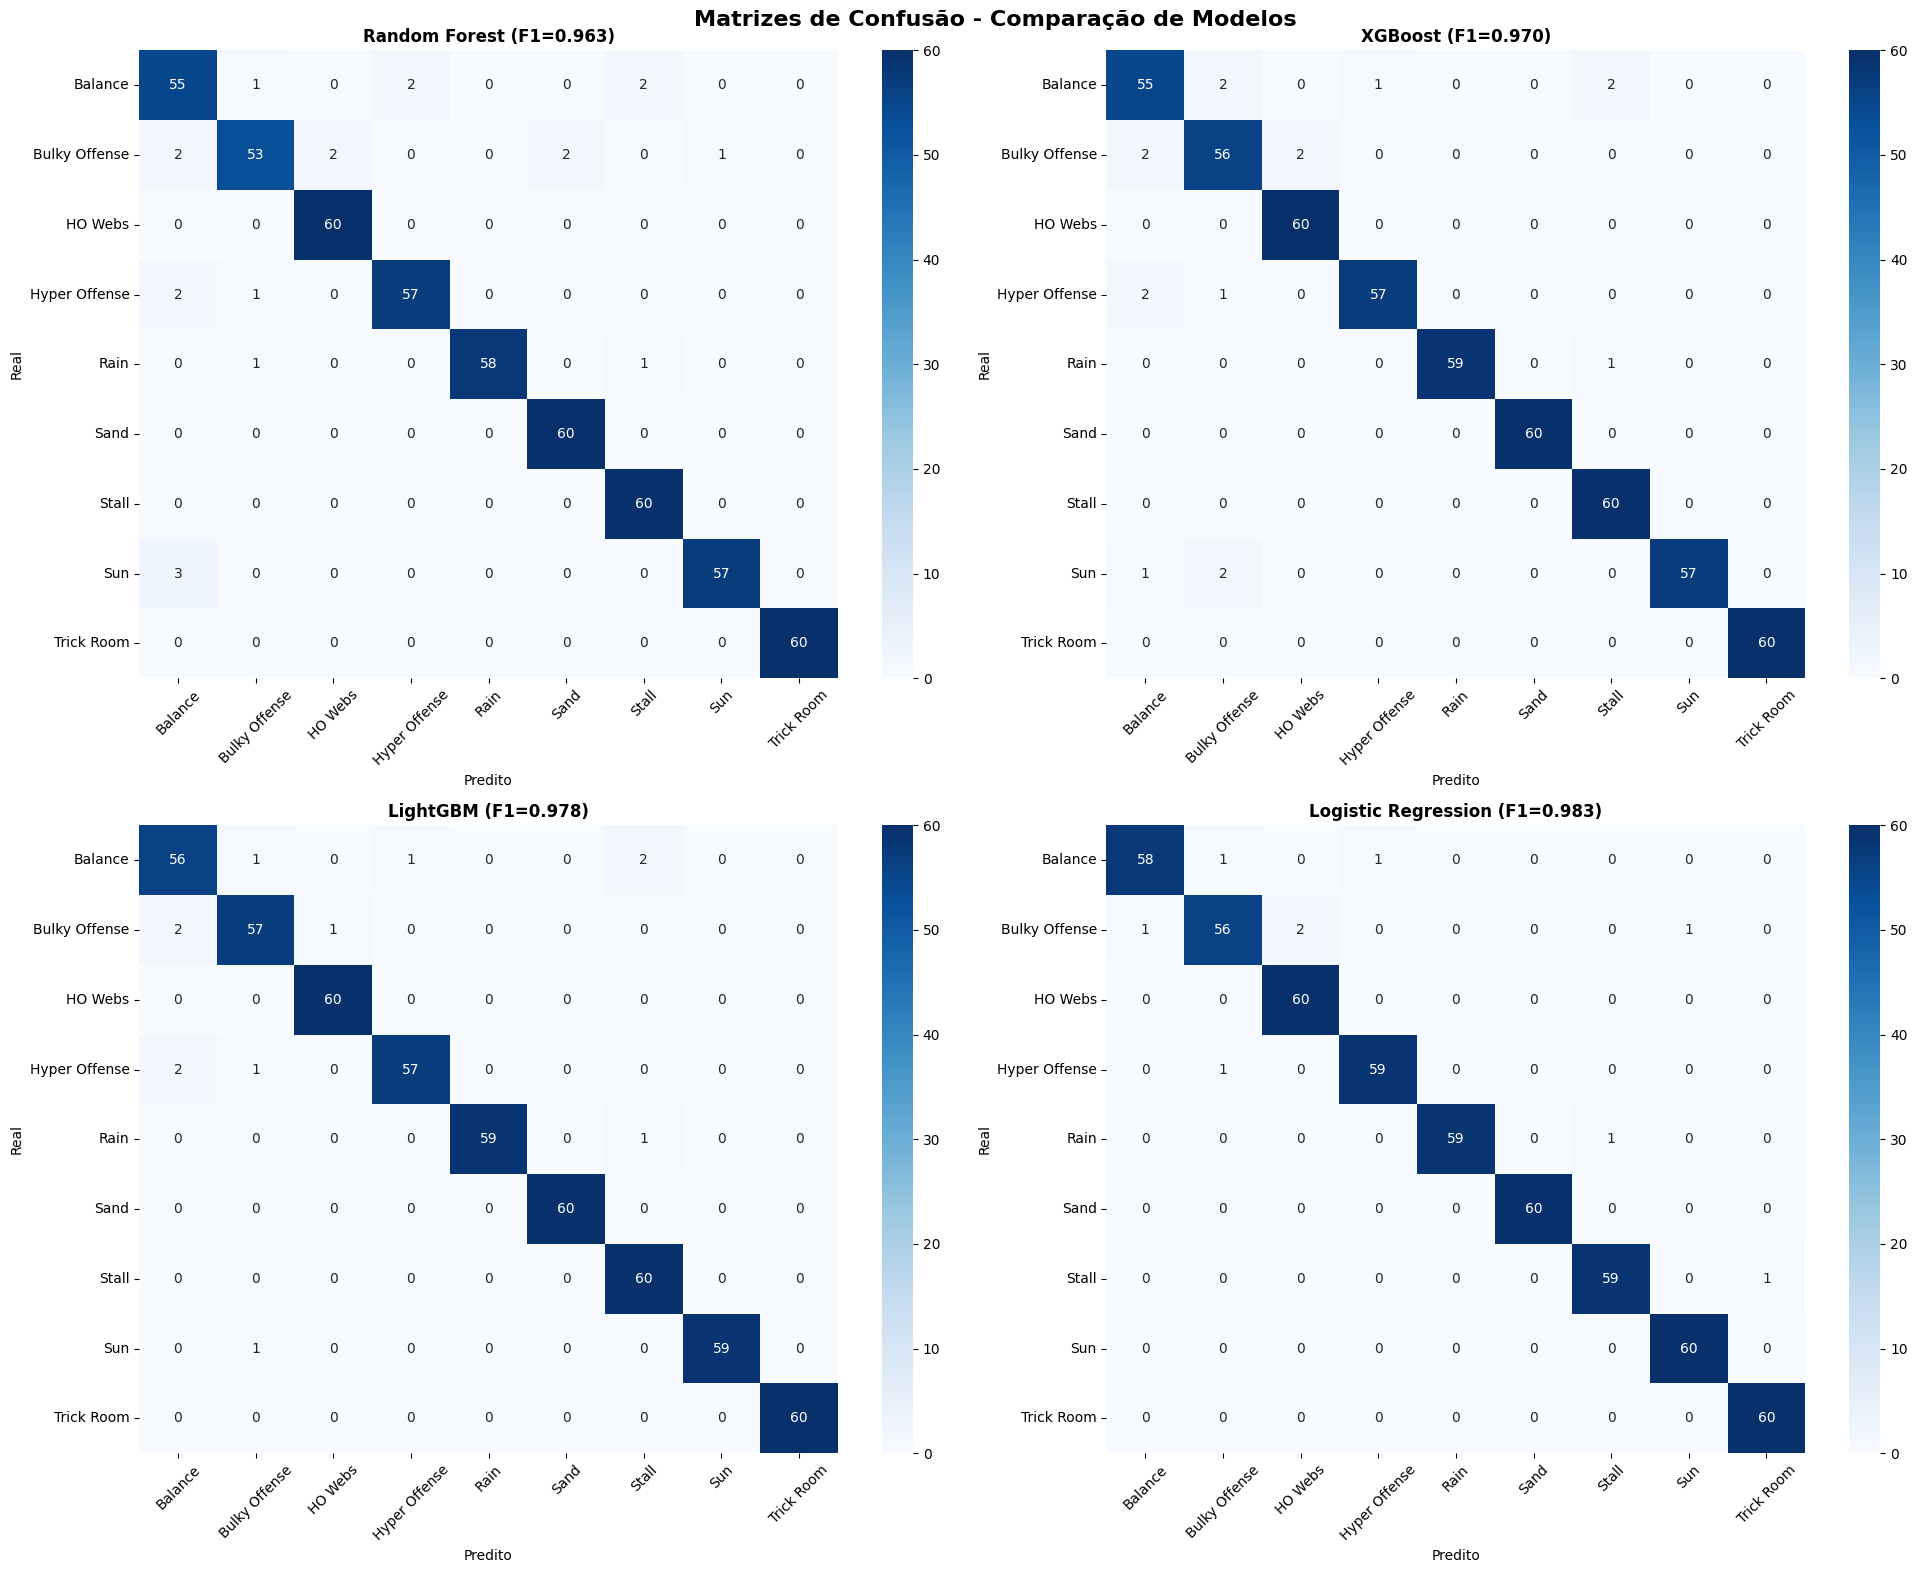

In [9]:
# Report do melhor modelo
best_name,best_data=best
print(f"📊 Classification Report - {best_name}:\n")
print(classification_report(y_test,best_data["y_pred"],target_names=le.classes_))

# Confusion Matrix
fig,axes=plt.subplots(2,2,figsize=(20,16))
for ax,(name,data) in zip(axes.flat,results.items()):
    cm=confusion_matrix(y_test,data["y_pred"])
    sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',xticklabels=le.classes_,
                yticklabels=le.classes_,ax=ax)
    ax.set_title(f"{name} (F1={data['f1']:.3f})",fontsize=12,fontweight='bold')
    ax.set_xlabel("Predito"); ax.set_ylabel("Real")
    ax.tick_params(axis='x',rotation=45); ax.tick_params(axis='y',rotation=0)
plt.suptitle("Matrizes de Confusão - Comparação de Modelos",fontsize=16,fontweight='bold')
plt.tight_layout(); plt.savefig("confusion_matrices.png",dpi=150,bbox_inches='tight')
plt.show()

# Feature importance
if hasattr(best_data["model"],"feature_importances_"):
    imp=pd.Series(best_data["model"].feature_importances_,index=X.columns).sort_values(ascending=False)[:20]
    plt.figure(figsize=(12,6))
    imp.plot(kind='barh',color='steelblue')
    plt.title(f"Top 20 Features - {best_name}",fontsize=14,fontweight='bold')
    plt.xlabel("Importância"); plt.tight_layout()
    plt.savefig("feature_importance.png",dpi=150); plt.show()

## 7. Função classify_team()

In [13]:
final_model = best_data["model"]
use_scaled_final = best_name == "Logistic Regression"

def classify_team(team_names):
    """Classifica o archetype de um time Pokémon com busca robusta de nomes.
    Args: team_names: lista de nomes de Pokémon
    Returns: archetype predito e probabilidades"""
    team = []
    for name in team_names:
        # Normalização do input: minúsculo e sem hífens/espaços
        clean_input = name.lower().replace(" ", "").replace("-", "")
        match = None

        # 1. Busca exata ou por chave normalizada
        for pname, pdata in pokemon_db.items():
            pname_clean = pname.lower().replace("-", "")
            if pname_clean == clean_input:
                match = pdata
                break

        # 2. Busca por substring se não encontrar exato (ex: 'rotomwash' in 'rotom-wash')
        if not match:
            for pname, pdata in pokemon_db.items():
                pname_clean = pname.lower().replace("-", "")
                if clean_input in pname_clean or pname_clean in clean_input:
                    match = pdata
                    break

        if match:
            team.append(match)
        else:
            print(f"⚠️ '{name}' não encontrado nos dados coletados")

    if len(team) < 1:
        print("❌ Nenhum Pokémon válido encontrado.")
        return None

    if len(team) < 6:
        print(f"ℹ️ Analisando time incompleto: {len(team)}/6 Pokémon")

    # Extração de features
    feats = pd.DataFrame([extract_features(team)])
    for c in X.columns:
        if c not in feats.columns: feats[c] = 0
    feats = feats[X.columns]

    # Predição
    inp = scaler.transform(feats) if use_scaled_final else feats
    pred = final_model.predict(inp)[0]
    label = le.inverse_transform([pred])[0]

    print(f"\n🎮 Time: {[p['name'].title() for p in team]}")
    print(f"🏷️ Archetype: {label}")

    if hasattr(final_model, 'predict_proba'):
        probs = final_model.predict_proba(inp)[0]
        top3 = sorted(zip(le.classes_, probs), key=lambda x: x[1], reverse=True)[:3]
        print("📊 Top 3 probabilidades:")
        for cls, prob in top3: print(f"   {cls}: {prob:.2%}")
    return label

print("✅ Função classify_team() atualizada com busca robusta!")

✅ Função classify_team() atualizada com busca robusta!


## 8. Exemplos Reais

In [11]:
print("="*60)
print("EXEMPLO 1: Sand Balance")
classify_team(["Tyranitar","Excadrill","Rotom-Wash","Ferrothorn","Gliscor","Latios"])
print("\n"+"="*60)
print("EXEMPLO 2: Rain")
classify_team(["Pelipper","Barraskewda","Ferrothorn","Zapdos","Swampert","Tornadus"])
print("\n"+"="*60)
print("EXEMPLO 3: Hyper Offense")
classify_team(["Dragapult","Weavile","Kartana","Tapu-Lele","Garchomp","Bisharp"])
print("\n"+"="*60)
print("EXEMPLO 4: Stall")
classify_team(["Toxapex","Chansey","Skarmory","Quagsire","Clefable","Mandibuzz"])

EXEMPLO 1: Sand Balance

🎮 Time: ['Tyranitar', 'Excadrill', 'Rotom', 'Ferrothorn', 'Gliscor', 'Latios']
🏷️ Archetype: Sand
📊 Top 3 probabilidades:
   Sand: 94.42%
   Balance: 3.53%
   Bulky Offense: 1.76%

EXEMPLO 2: Rain

🎮 Time: ['Pelipper', 'Barraskewda', 'Ferrothorn', 'Zapdos', 'Swampert', 'Tornadus-Incarnate']
🏷️ Archetype: Rain
📊 Top 3 probabilidades:
   Rain: 76.85%
   Bulky Offense: 20.20%
   Sand: 1.45%

EXEMPLO 3: Hyper Offense

🎮 Time: ['Dragapult', 'Weavile', 'Kartana', 'Tapu-Lele', 'Garchomp', 'Bisharp']
🏷️ Archetype: Hyper Offense
📊 Top 3 probabilidades:
   Hyper Offense: 90.56%
   Balance: 8.93%
   Bulky Offense: 0.51%

EXEMPLO 4: Stall

🎮 Time: ['Toxapex', 'Chansey', 'Skarmory', 'Quagsire', 'Clefable', 'Mandibuzz']
🏷️ Archetype: Balance
📊 Top 3 probabilidades:
   Balance: 96.63%
   Bulky Offense: 2.11%
   Trick Room: 1.10%


np.str_('Balance')

## 9. Exportação do Modelo

In [12]:
OUT=Path("team_classifier"); OUT.mkdir(exist_ok=True)
import joblib
joblib.dump(final_model,OUT/"model.joblib")
joblib.dump(scaler,OUT/"scaler.joblib")
joblib.dump(le,OUT/"label_encoder.joblib")
X.columns.to_series().to_csv(OUT/"feature_names.csv",index=False)
print("✅ Modelo exportado!")
for f in OUT.iterdir(): print(f"   📁 {f.name} ({f.stat().st_size/1024:.1f}KB)")
!cd team_classifier && zip -r ../team_classifier.zip .
print("📦 Compactado: team_classifier.zip")

✅ Modelo exportado!
   📁 label_encoder.joblib (0.8KB)
   📁 feature_names.csv (0.7KB)
   📁 scaler.joblib (3.2KB)
   📁 model.joblib (5.5KB)
  adding: label_encoder.joblib (deflated 55%)
  adding: feature_names.csv (deflated 60%)
  adding: scaler.joblib (deflated 28%)
  adding: model.joblib (deflated 9%)
📦 Compactado: team_classifier.zip
